In [2]:
from lib.contact_settings import *
from lib.contact_material import material
from lib.geoLib.contact_wheel_rail import wheel, rail
from lib.dynLib.contact_dyn_state import dynamic_state
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pio_normal_contact
from lib.normLib.contact_solver import NormalContactSolver
from lib.tanLib.tangent_methods import fastsim, tangent_creepage
from lib.contact_material import kalker_coefficients
import matplotlib.pyplot as plt


In [2]:
dy = 0  # -3e-3

Wheel = wheel()
Rail = rail(rail_inclination=30)

material_model = material()

n_patches = 3
contact_eq = NormalContactSolver(eqv_el_normal_contact(), n_patches)

new_state = dynamic_state(state_y=dy, state_z=1e-4, state_roll=0, state_yaw=0)
Wheel.set_dynamic_state(new_state)
Wheel.calculate_position()

contact_eq.patch_search(Wheel, Rail, material_model)

In [3]:
print(Wheel.wheel_radius)

[[0.68013    0.47182419]
 [0.68013095 0.47183188]
 [0.6801319  0.47183956]
 ...
 [0.8102718  0.45734596]
 [0.81027935 0.45734545]
 [0.8102869  0.45734494]]


NameError: name 'Wheel' is not defined

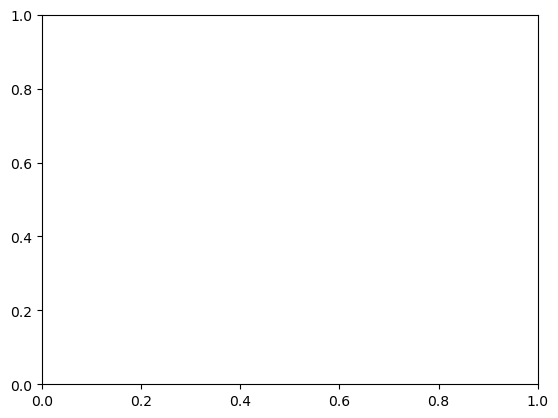

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(Wheel.wheel_radius[:, 0], Wheel.wheel_radius[:, 1])
ax.set_aspect("equal")

radius_inerpolator = PchipInterpolator(
    Wheel.wheel_radius[:, 0], Wheel.wheel_radius[:, 1]
)
try:
    contact_radius = radius_inerpolator(contact_eq.contact_patches[0].centroid_wheel[0])
    ax.scatter(contact_eq.contact_patches[0].centroid_wheel[0], contact_radius, c="red")
    print(contact_eq.contact_patches[0].centroid_wheel[0])
except:
    contact_radius = None

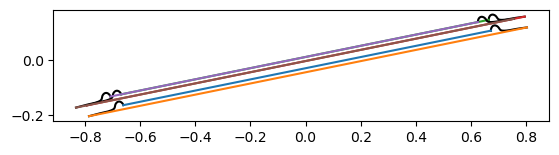

In [16]:
fig, ax = plt.subplots()

for jj in range(4,5):
    Wheel_L = wheel(lr=LEFT)

    new_state = dynamic_state(state_roll=jj / 20, state_z = -jj/100)#, state_z = jj/100)
    Wheel_L.set_dynamic_state(new_state)
    Wheel_L.calculate_position()

    ax.plot(Wheel_L.wheel_profile_pos[:, 0], Wheel_L.wheel_profile_pos[:, 1], c="black")
    
    Wheel_R = wheel(lr=RIGHT)

    new_state = dynamic_state(state_roll=jj / 20, state_z = -jj/100)#, state_z = jj/100)
    Wheel_R.set_dynamic_state(new_state)
    Wheel_R.calculate_position()

    ax.plot(Wheel_R.wheel_profile_pos[:, 0], Wheel_R.wheel_profile_pos[:, 1], c="black")

    ax.plot([Wheel_R.wheel_profile_pos[0, 0], Wheel_L.wheel_profile_pos[-1, 0]], [Wheel_R.wheel_profile_pos[0, 1], Wheel_L.wheel_profile_pos[-1, 1]])
    ax.plot([Wheel_R.wheel_profile_pos[-1, 0], Wheel_L.wheel_profile_pos[0, 0]], [Wheel_R.wheel_profile_pos[-1, 1], Wheel_L.wheel_profile_pos[0, 1]])
    
    new_state = dynamic_state(state_roll=jj / 20)#, state_z = -jj/100, state_z = jj/100)
    Wheel_L.set_dynamic_state(new_state)
    Wheel_L.calculate_position()

    ax.plot(Wheel_L.wheel_profile_pos[:, 0], Wheel_L.wheel_profile_pos[:, 1], c="black")
    
    Wheel_R = wheel(lr=RIGHT)

    new_state = dynamic_state(state_roll=jj / 20)#, state_z = -jj/100, state_z = jj/100)
    Wheel_R.set_dynamic_state(new_state)
    Wheel_R.calculate_position()

    ax.plot(Wheel_R.wheel_profile_pos[:, 0], Wheel_R.wheel_profile_pos[:, 1], c="black")

    ax.plot([Wheel_R.wheel_profile_pos[0, 0], Wheel_L.wheel_profile_pos[-1, 0]], [Wheel_R.wheel_profile_pos[0, 1], Wheel_L.wheel_profile_pos[-1, 1]])
    ax.plot([Wheel_R.wheel_profile_pos[-1, 0], Wheel_L.wheel_profile_pos[0, 0]], [Wheel_R.wheel_profile_pos[-1, 1], Wheel_L.wheel_profile_pos[0, 1]])
    
    new_state = dynamic_state(state_roll=jj / 20, state_y = -jj/100)#, state_z = jj/100)
    Wheel_L.set_dynamic_state(new_state)
    Wheel_L.calculate_position()

    ax.plot(Wheel_L.wheel_profile_pos[:, 0], Wheel_L.wheel_profile_pos[:, 1], c="black")
    
    Wheel_R = wheel(lr=RIGHT)

    new_state = dynamic_state(state_roll=jj / 20, state_y = -jj/100)#, state_z = jj/100)
    Wheel_R.set_dynamic_state(new_state)
    Wheel_R.calculate_position()

    ax.plot(Wheel_R.wheel_profile_pos[:, 0], Wheel_R.wheel_profile_pos[:, 1], c="black")

    ax.plot([Wheel_R.wheel_profile_pos[0, 0], Wheel_L.wheel_profile_pos[-1, 0]], [Wheel_R.wheel_profile_pos[0, 1], Wheel_L.wheel_profile_pos[-1, 1]])
    ax.plot([Wheel_R.wheel_profile_pos[-1, 0], Wheel_L.wheel_profile_pos[0, 0]], [Wheel_R.wheel_profile_pos[-1, 1], Wheel_L.wheel_profile_pos[0, 1]])

ax.set_aspect("equal")

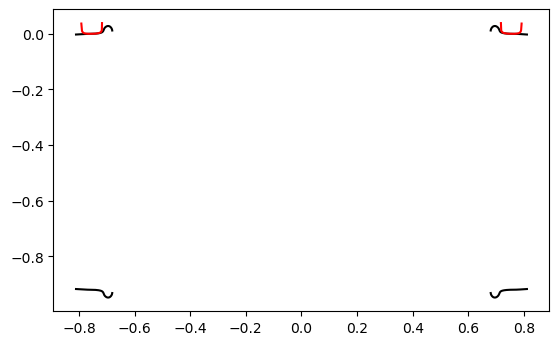

In [6]:
Wheel_R, Wheel_L = wheel(), wheel(lr=LEFT)
Rail_R, Rail_L = rail(), rail(lr=LEFT)

fig, ax = plt.subplots()
ax.plot(Wheel_R.wheel_profile_pos[:, 0], Wheel_R.wheel_profile_pos[:, 1], c="k")
ax.plot(
    Wheel_R.wheel_profile_pos[:, 0],
    -2 * Wheel_R.r0 - (Wheel_R.wheel_profile_pos[:, 1]),
    c="k",
)
ax.plot(Wheel_L.wheel_profile_pos[:, 0], Wheel_L.wheel_profile_pos[:, 1], c="k")
ax.plot(
    Wheel_L.wheel_profile_pos[:, 0],
    -2 * Wheel_L.r0 - (Wheel_L.wheel_profile_pos[:, 1]),
    c="k",
)
ax.plot(Rail_R.rail_profile_pos[:, 0], Rail_R.rail_profile_pos[:, 1], c="r")
ax.plot(Rail_L.rail_profile_pos[:, 0], Rail_L.rail_profile_pos[:, 1], c="r")
ax.set_aspect("equal")

In [7]:
import numpy as np
from scipy.integrate import solve_ivp


def dynamics(t, x, k, c, u_func):
    x1, x2 = x

    # external input
    u = u_func(t)

    dx1 = x2
    dx2 = -k * x1 - c * x2 + u
    return [dx1, dx2]


# external force or input
def my_force(t):
    return 0.5 * np.sin(2 * t)


x0 = [1.0, 0.0]
tspan = (0, 10)
t_eval = np.linspace(0, 10, 200)

sol = solve_ivp(
    dynamics,
    tspan,
    x0,
    t_eval=t_eval,
    args=(1.0, 0.2, my_force),  # pass extra parameters
)

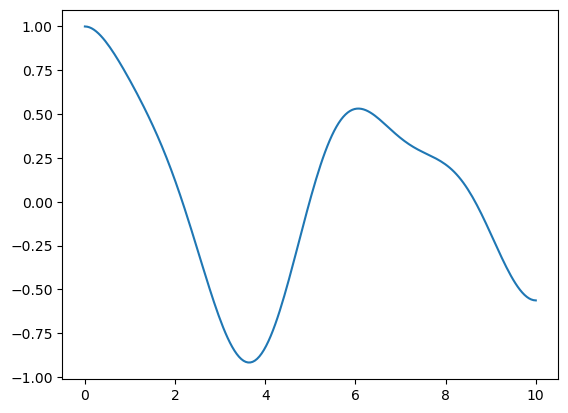

In [8]:
fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[0, :])

In [9]:
def dynamics(
    t,
    x,
    wheels: wheel,
    rails: rail,
    contact_eq_s,
    material_model,
    tangent_method,
    kalker_tables,
    wheelset_mass,
):

    dx = np.zeros_like(x)
    q = x[0:6]
    v = x[6:12]

    dx[0:6] = v

    new_state = dynamic_state(
        state_x=q[0],
        state_y=q[1],
        state_z=q[2],
        state_pitch=q[3],
        state_yaw=q[4],
        state_roll=q[5],
        state_v_x=v[0],
        state_v_y=v[1],
        state_v_z=v[2],
        state_v_pitch=v[3],
        state_v_yaw=v[4],
        state_v_roll=v[5],
    )

    F_vector = np.zeros(6)

    for index, wheel in enumerate(wheels):

        wheel.set_dynamic_state(new_state)
        wheel.calculate_position()

        contact_eq_s[index].patch_search(wheel, rails[index], material_model)
        # radius_inerpolator = PchipInterpolator(
        #     wheel.wheel_radius[:, 0], wheel.wheel_radius[:, 1]
        # )

        for contacts in contact_eq_s[index].contact_patches:
            contact_radius = contacts.Rlocal
            delta_r = wheel.r0 - contact_radius
            if contacts.centroid_wheel != 0.0:
                if wheel.lr == RIGHT:
                    nu_x = -(
                        delta_r / wheel.r0
                        + np.abs(contacts.centroid_wheel) / 2 * v[4] / v[0]
                    )
                elif wheel.lr == LEFT:
                    nu_x = -(
                        delta_r / wheel.r0
                        - np.abs(contacts.centroid_wheel) / 2 * v[4] / v[0]
                    )

                nu_y = 1 / np.cos(contacts.contact_angle) * (v[1] / v[0] - q[4])
                phi = -np.cos(contacts.contact_angle) / wheel.r0 + v[4] / v[0] * np.cos(
                    contacts.contact_angle
                )

                creep = tangent_creepage(nu_x=nu_x, nu_y=nu_y, phi=phi)

                tangent_method.calc_tangent_force(
                    contacts, material_model, kalker_tables, creep, new_state
                )

                F_vector[0] += tangent_method.F_x
                F_vector[1] += contacts.Y_force + tangent_method.F_y
                F_vector[2] += contacts.Q_force
                F_vector[3] -= contact_radius.item() * tangent_method.F_x
                F_vector[4] += contacts.centroid_wheel.item() * tangent_method.F_x
                F_vector[5] += contacts.centroid_wheel.item() * contacts.Q_force

    dx[6:12] = F_vector / wheelset_mass

    # print(f"doing...{t}")

    return dx

In [10]:
wheels = [wheel(), wheel(lr=LEFT)]
rails = [rail(), rail(lr=LEFT)]

n_patches = 3
contact_eqs = [
    NormalContactSolver(eqv_el_normal_contact(), n_patches),
    NormalContactSolver(eqv_el_normal_contact(), n_patches),
]

kalker_tables = kalker_coefficients(material_properties=material_model)
fastsim_patch = fastsim()

In [11]:
from calc_routines.determine_static_contact import static_contact

wheelset_mass = 750.0
I_x = 80.0
I_y = 350.0
I_z = 350.0

patches_per_deltays_eq, result_state_pressure_eq = static_contact(
    [0],
    wheels[0],
    rails[0],
    contact_eqs[0],
    material_model,
    Q_solve=wheelset_mass * 9.81 / 2,
)

x0 = np.zeros(12)
x0[2] = patches_per_deltays_eq["patch_0"][0][0]
x0[6] = 100 / 3.6

mass_vector = np.array([wheelset_mass, wheelset_mass, wheelset_mass, I_x, I_y, I_z])

100%|██████████| 1/1 [00:00<00:00, 15.91it/s]


In [12]:
# def velocity_verlet_step(x, v, a, dt, force_func):
#     x_new = x + v*dt + 0.5*a*dt**2
#     a_new = force_func(x_new)
#     v_new = v + 0.5*(a + a_new)*dt
#     return x_new, v_new, a_new


def velocity_verlet_step(
    x,
    a_old,
    dt,
    force_func,
    wheels,
    rails,
    contact_eqs,
    material_model,
    fastsim_patch,
    kalker_tables,
    mass_vector,
):
    x_old = x[0:6]
    v_old = x[0:6]
    x_new_star = x_old + v_old * dt + 0.5 * a_old * dt**2
    x_new = np.stack((x_new_star, x[6:12]), axis=0).flatten()
    a_star = force_func(
        0,
        x_new,
        wheels,
        rails,
        contact_eqs,
        material_model,
        fastsim_patch,
        kalker_tables,
        mass_vector,
    )
    a_new = a_star[6:12]
    v_new = x[6:12] + 0.5 * (a_old + a_new) * dt
    return x_new_star, v_new, a_new

In [13]:
# tspan = (0, 4)
# dt = 1e-4

# t_eval = np.arange(tspan[0], tspan[1] + dt, dt)

# fig, ax = plt.subplots()
# x_old = x0
# a_old = np.zeros(6)
# for jj in range(len(t_eval)):
#     x_new, v_new, a_new = velocity_verlet_step(
#         x_old,
#         a_old,
#         dt,
#         dynamics,
#         wheels,
#         rails,
#         contact_eqs,
#         material_model,
#         fastsim_patch,
#         kalker_tables,
#         mass_vector,
#     )
#     x_old = np.stack((x_new, v_new), axis=0).flatten()
#     a_old = a_new
#     print(f"Time: {t_eval[jj]:.4f} s")

In [14]:
# dx = dynamics(0, x0, wheels, rails, contact_eqs, material_model, fastsim_patch, kalker_tables, mass_vector)

tspan = (0, 0.3)
# t_eval = np.linspace(0, 2, 10)

dt = 1e-2
t_eval = np.arange(tspan[0], tspan[1] + dt, dt)
print(len(t_eval))
sol = solve_ivp(
    dynamics,
    tspan,
    x0,
    t_eval=t_eval,
    method="RK45",
    max_step=dt,
    args=(
        wheels,
        rails,
        contact_eqs,
        material_model,
        fastsim_patch,
        kalker_tables,
        mass_vector,
    ),  # pass extra parameters
)

31


KeyboardInterrupt: 

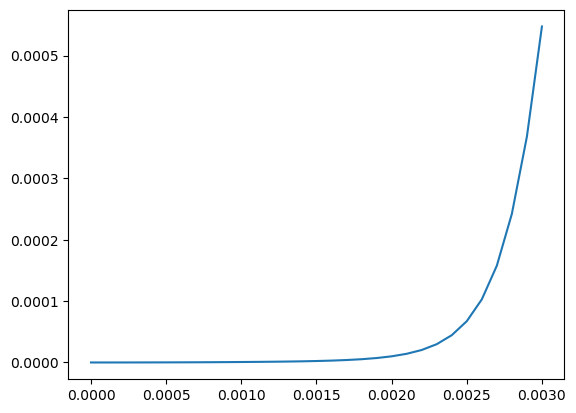

In [ ]:
fig, ax = plt.subplots()
ax.plot(sol.t, sol.y[1, :])